### Import Libraries

In [1]:
import duckdb
import pandas as pd
import numpy as np
import time
import re
import warnings
warnings.filterwarnings("ignore")

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from gensim.models import Word2Vec
from gensim.models import KeyedVectors

### Anthropic Client

In [2]:
import anthropic
import os
from dotenv import load_dotenv

load_dotenv()
client = anthropic.Anthropic(api_key=os.getenv('ANTHROPIC_API_KEY'))

### Source Data

This notebook builds on the translation work completed across three prior notebooks:
- `02_submit_batch.ipynb` — submitted 49K requests (messages + titles) to Anthropic's Batch API for asynchronous processing
- `03_retrieve_batch.ipynb` — retrieved and saved batch translation results to `llm_outputs.translated_reviews`
- `04_combine_translations.ipynb` — merged batch translations with lookup-based translations for short reviews, producing a single enriched dataset saved to `llm_outputs.review_translations_final`

All translation logic is encapsulated in those notebooks. This notebook loads directly from `llm_outputs.review_translations_final` and focuses solely on sentiment analysis. <br>
We use that as our source here rather than raw data, so translations are not recomputed.

In [3]:
conn = duckdb.connect('/app/data/analytics.duckdb')

In [4]:
## All reviews
df = conn.execute("""
                    SELECT *
                    FROM llm_outputs.review_translations_final
                """).df()

print("Shape -", df.shape)
df.head(n=2)

Shape - (98410, 7)


,review_id,review_score,review_comment_message,review_comment_title,message_length,translated_message,translated_title
0,72730619a00e0ecdecf0a4ff862d8996,1,comprei tres pacotes de cinco folhas cada de p...,None,95.0,I bought three packages of five sheets each of...,None
1,56c957e848b3f71bcebd87e12b7883d7,4,None,None,NaN,None,None


### EDA

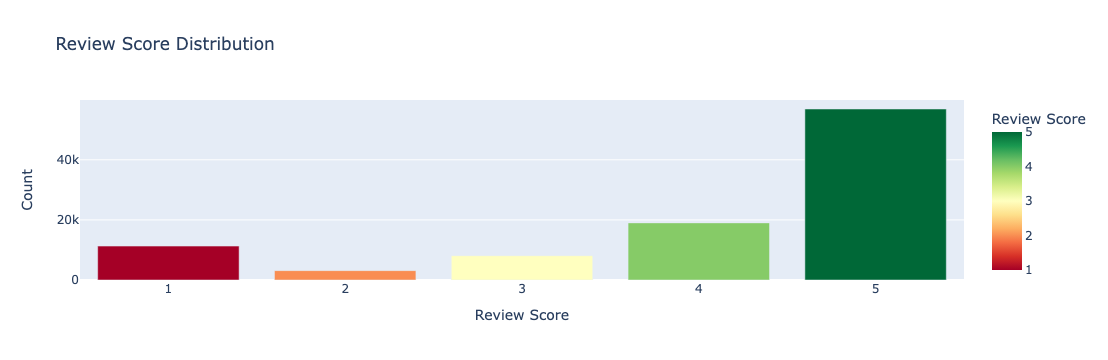

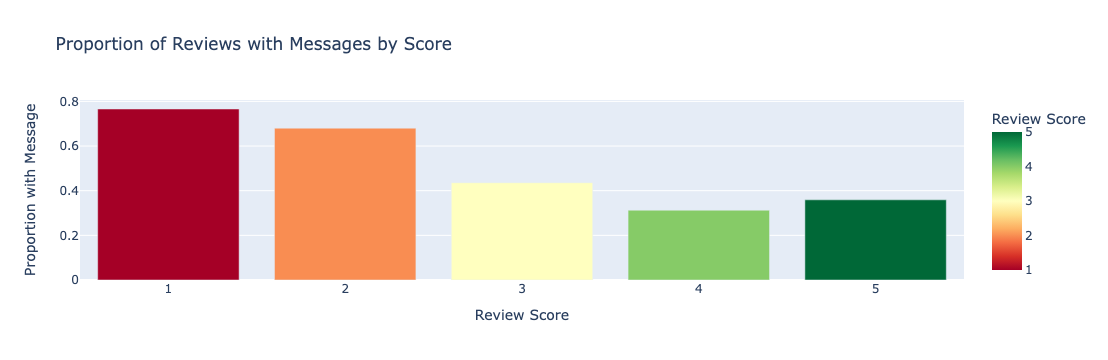

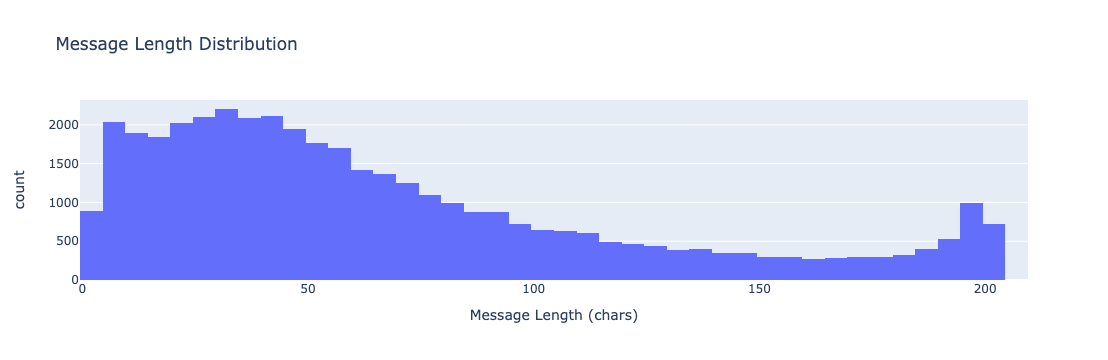

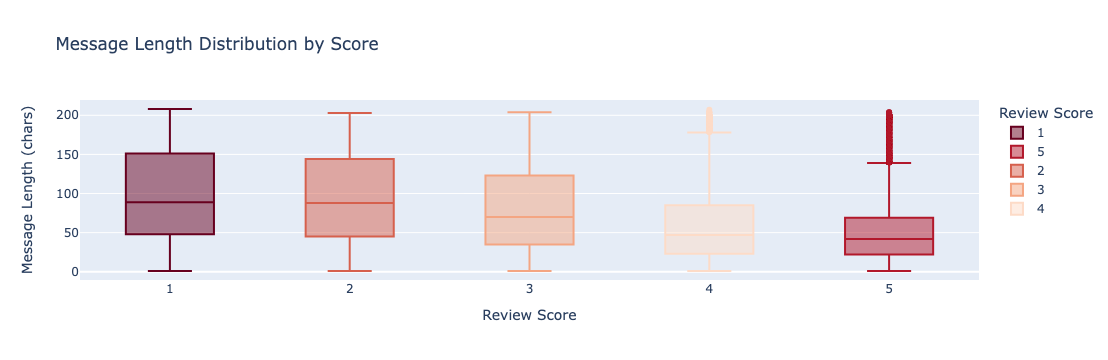

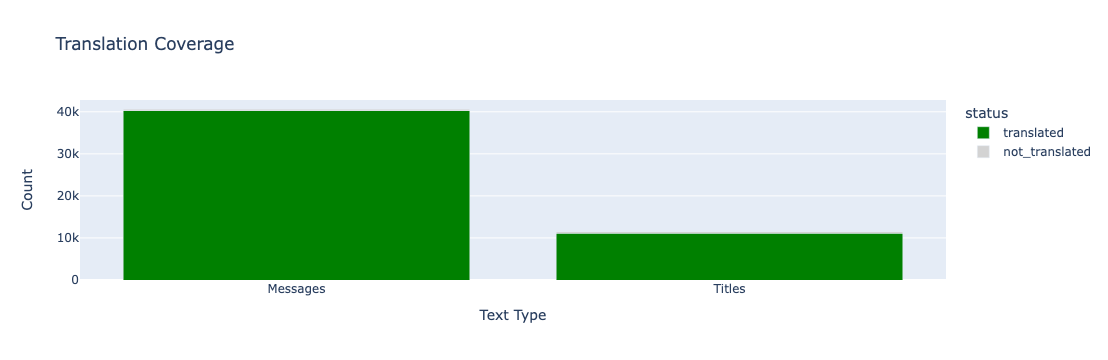

In [5]:
# 1. Review Score Distribution
fig1 = px.bar(
    df['review_score'].value_counts().sort_index().reset_index(),
    x='review_score',
    y='count',
    title='Review Score Distribution',
    labels={'review_score': 'Review Score', 'count': 'Count'},
    color='review_score',
    color_continuous_scale='RdYlGn'
)
fig1.show()

# 2. Message presence by score
df['has_message'] = df['review_comment_message'].notna()
message_by_score = df.groupby('review_score')['has_message'].agg(['sum', 'count'])
message_by_score['pct_with_message'] = message_by_score['sum'] / message_by_score['count']
message_by_score = message_by_score.reset_index()

fig2 = px.bar(
    message_by_score,
    x='review_score',
    y='pct_with_message',
    title='Proportion of Reviews with Messages by Score',
    labels={'review_score': 'Review Score', 'pct_with_message': 'Proportion with Message'},
    color='review_score',
    color_continuous_scale='RdYlGn'
)
fig2.show()

# 3. Message length histogram
df_with_msg = df[df['message_length'].notna()]

fig3 = px.histogram(
    df_with_msg,
    x='message_length',
    title='Message Length Distribution',
    labels={'message_length': 'Message Length (chars)', 'count': 'Count'},
    nbins=50
)
fig3.show()

# 4. Message length distribution by score
fig4 = px.box(
    df_with_msg,
    x='review_score',
    y='message_length',
    title='Message Length Distribution by Score',
    labels={'review_score': 'Review Score', 'message_length': 'Message Length (chars)'},
    color='review_score',
    color_discrete_sequence=px.colors.sequential.RdBu
)
fig4.show()

# 5. Translation coverage
coverage = pd.DataFrame({
    'type': ['Messages', 'Titles'],
    'translated': [df['translated_message'].notna().sum(), df['translated_title'].notna().sum()],
    'not_translated': [df['has_message'].sum() - df['translated_message'].notna().sum(),
                       df['review_comment_title'].notna().sum() - df['translated_title'].notna().sum()]
})
coverage_melted = coverage.melt(id_vars='type', var_name='status', value_name='count')

fig5 = px.bar(
    coverage_melted,
    x='type',
    y='count',
    color='status',
    title='Translation Coverage',
    labels={'type': 'Text Type', 'count': 'Count'},
    color_discrete_map={'translated': 'green', 'not_translated': 'lightgray'},
    barmode='stack'
)
fig5.show()

### Text Pre-processing

#### Filter Reviews with Messages or Titles

In [6]:
df_model = df[df['translated_message'].notna() | df['translated_title'].notna()].reset_index(drop=True)

print(f"Reviews with at least one translation: {len(df_model):,}")
print(f"Dropped (no text content): {len(df) - len(df_model):,}")

Reviews with at least one translation: 41,940
Dropped (no text content): 56,470


In [8]:
stop_words = set(stopwords.words('english'))

# Remove negation words from stopwords
negation_words = {'not', 'no', 'never', 'neither', 'nor', 'nothing', 
                  'nowhere', 'hardly', 'barely', 'scarcely', "don't", 
                  "didn't", "doesn't", "wasn't", "isn't", "aren't", 
                  "won't", "wouldn't", "couldn't", "shouldn't"}
lemmatizer = WordNetLemmatizer()

# Combine title + message into combined_text (raw, for LSTM/GloVe/Claude)
df_model['combined_text'] = df_model['translated_title'].fillna('') + ' ' + df_model['translated_message'].fillna('')
df_model['combined_text'] = df_model['combined_text'].str.strip().str.lower() 

# Transform to lowercase and remove special characters for VADER
def vader_text(text):
    # Lowercase
    text = text.lower()
    # Remove special chars but keep spaces
    text = re.sub(r'[^a-z\s]', '', text)
    return text.strip()

df_model['vader_text'] = df_model['combined_text'].apply(vader_text)

# Transform to lowercase, remove special characters, Tokenize, remove stopwords, lemmatize for TF-IDF
def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove special chars and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize, remove stopwords, lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in text.split()
              if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

df_model['clean_text'] = df_model['combined_text'].apply(clean_text)

df_model[['combined_text', 'vader_text', 'clean_text']].head(3)

,combined_text,vader_text,clean_text
0,i bought three packages of five sheets each of...,i bought three packages of five sheets each of...,bought three package five sheet transfer paper...
1,excellent i had excellent after-sales service ...,excellent i had excellent aftersales service t...,excellent excellent aftersales service renato
2,"beautiful product, great",beautiful product great,beautiful product great


### Modeling

#### VADER Sentiment Analysis

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a lexicon-based sentiment analysis tool that scores individual words against a pre-built sentiment dictionary, combining them into a compound score between -1 (most negative) and +1 (most positive).

Unlike ML models, VADER requires no training data and works out of the box; making it a useful baseline to compare against our TF-IDF and LLM-based approaches.

In [9]:
# Initialize VADER
analyzer = SentimentIntensityAnalyzer()

# Test
for i, row in df_model.head(5).iterrows():
    scores = analyzer.polarity_scores(row['vader_text'])
    print(f"Review: {row['vader_text'][:200]}...")
    print(f"Score: {row['review_score']} | VADER: {scores}")
    print()

Review: i bought three packages of five sheets each of transfer paper for dark fabric and i only received two...
Score: 1 | VADER: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}

Review: excellent i had excellent aftersales service through mr renato...
Score: 5 | VADER: {'neg': 0.0, 'neu': 0.486, 'pos': 0.514, 'compound': 0.8126}

Review: beautiful product great...
Score: 5 | VADER: {'neg': 0.0, 'neu': 0.111, 'pos': 0.889, 'compound': 0.8402}

Review: product delivered...
Score: 5 | VADER: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}

Review: product with defect i purchased  units of the product and they arrived damaged since the packaging is very weak they came with two holes in the bottom of the pot due to the pressure of the dog being p...
Score: 1 | VADER: {'neg': 0.212, 'neu': 0.753, 'pos': 0.036, 'compound': -0.8357}



In [10]:
# Apply VADER to all reviews
df_model['vader_scores'] = df_model['vader_text'].apply(
    lambda x: analyzer.polarity_scores(str(x)) if pd.notna(x) else None
)

df_model['vader_compound'] = df_model['vader_scores'].apply(lambda x: x['compound'] if x else None)
df_model['vader_neg'] = df_model['vader_scores'].apply(lambda x: x['neg'] if x else None)
df_model['vader_pos'] = df_model['vader_scores'].apply(lambda x: x['pos'] if x else None)
df_model['vader_neu'] = df_model['vader_scores'].apply(lambda x: x['neu'] if x else None)

# Map compound score to sentiment label
def compound_to_label(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df_model['vader_sentiment'] = df_model['vader_compound'].apply(
    lambda x: compound_to_label(x) if pd.notna(x) else None
)

df_model['vader_sentiment'].value_counts()

vader_sentiment
positive    26871
neutral      8387
negative     6682
Name: count, dtype: int64

In [11]:
# Compare VADER sentiment vs actual review score
pd.crosstab(df_model['review_score'], df_model['vader_sentiment'], normalize='index').round(2)

vader_sentiment,negative,neutral,positive
review_score,,,
1,0.46,0.37,0.17
2,0.40,0.36,0.24
3,0.27,0.30,0.43
4,0.09,0.17,0.74
5,0.02,0.11,0.88


In [12]:
df_model[(df_model['review_score']==2) & (df_model['vader_sentiment']=='neutral')][['review_id', 'vader_text']].head(n=2)

,review_id,vader_text
5,179527c47972453d440d9f65626945e4,i bought watches but only was delivered
86,bde9690c5e5c3b960a58b1114b007753,unfortunately we find online stores that in or...


In [13]:
df_model[(df_model['review_score']==5) & (df_model['vader_sentiment']=='neutral')][['review_id', 'vader_text']].head(n=2)

,review_id,vader_text
3,a19e0a3ad1dcda0f28ad1e37fff6ff27,product delivered
10,c000355ec678b0ebac410760c63464bd,the product arrived on time


<br> 

**Observations:**  
VADER captures the general sentiment trend well, negative sentiment dominates 1-2 star reviews while positive sentiment dominates 4-5 star reviews. 
- However, 1 and 2 star reviews show a surprisingly high neutral proportion (36-37%), suggesting VADER struggles with factual complaints like "The product has not arrived yet" which carries no emotionally charged words despite being clearly negative.
- It does better however with 4 and 5 star reviews (74%, 88%) positive sentiment, with small (17%, 11%) neutral sentiment. Reviews like "Arrived on time" are tagged as neutral, because there is no "positive" words in it, even though the sentiment is positive leaning. 

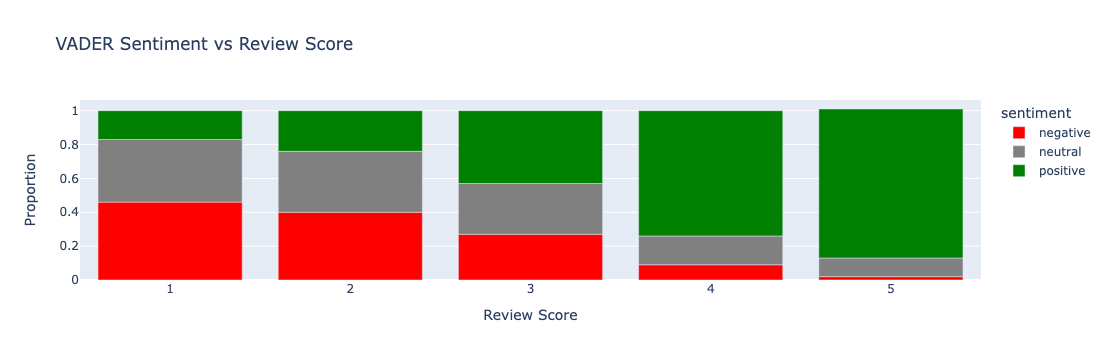

In [14]:
crosstab = pd.crosstab(df_model['review_score'],df_model['vader_sentiment'], normalize='index').round(2).reset_index()
crosstab_melted = crosstab.melt(id_vars='review_score', var_name='sentiment', value_name='proportion')

fig = px.bar(
    crosstab_melted,
    x='review_score',
    y='proportion',
    color='sentiment',
    color_discrete_map={'positive': 'green', 'neutral': 'gray', 'negative': 'red'},
    title='VADER Sentiment vs Review Score',
    labels={'review_score': 'Review Score', 'proportion': 'Proportion'}
)
fig.show()

**Observations:**  

The chart clearly shows the gradient from negative to positive as review scores increase. The large neutral band in 1-3 star reviews highlights VADER's key limitation; it is designed for emotionally expressive text and misses the subtle, factual language common in e-commerce complaints. This motivates our next approaches: TF-IDF, LSTM and LLM-based sentiment analysis.

#### Train-Test Split + TF-IDF vectorization

In [15]:
X = df_model['clean_text']
y = df_model['review_score']

print("Class distribution:")
print(y.value_counts().sort_index())
print(f"\nTotal samples: {len(X):,}")

Class distribution:
review_score
1     8684
2     2131
3     3582
4     6148
5    21395
Name: count, dtype: int64

Total samples: 41,940


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF vectorization
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),  # unigrams and bigrams
    min_df=2,            # ignore terms appearing in less than 2 docs
    strip_accents='unicode',
    lowercase=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Train size: {X_train_tfidf.shape}")
print(f"Test size: {X_test_tfidf.shape}")
print(f"Vocabulary size: {len(tfidf.vocabulary_):,}")

Train size: (33552, 5000)
Test size: (8388, 5000)
Vocabulary size: 5,000


##### Create a Results DF to store all model results

In [17]:
results_df = pd.DataFrame(columns=['Model', 'Accuracy', 'F1 Macro'])

#### TF-IDF Classifications

We evaluate three classifiers that represent different learning strategies:

- **Logistic Regression** — a strong linear baseline for text classification. Works well with high-dimensional sparse features like TF-IDF vectors, is fast to train, and highly interpretable.
- **Linear SVM** — similar to Logistic Regression but optimizes a different objective (margin maximization). Often performs slightly better on text data, especially with clear class boundaries.
- **Random Forest** — an ensemble of decision trees that captures non-linear patterns. Included as a contrast to the linear models, though it typically struggles with high-dimensional sparse text features.

We expect Logistic Regression and Linear SVM to outperform Random Forest here given the nature of TF-IDF features, and we are running all models with and without class weights balanced for comparison.

In [18]:
classifiers = {
    'TF-IDF + Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'TF-IDF + Logistic Regression (balanced)': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'TF-IDF + LinearSVC': LinearSVC(max_iter=1000, random_state=42),
    'TF-IDF + LinearSVC (balanced)': LinearSVC(max_iter=1000, random_state=42, class_weight='balanced'),
    'TF-IDF + Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'TF-IDF + Random Forest (balanced)': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
}

results = {}

for name, clf in classifiers.items():
    start = time.time()
    clf.fit(X_train_tfidf, y_train)
    y_pred = clf.predict(X_test_tfidf)
    elapsed = time.time() - start
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    results[name] = {'accuracy': acc, 'f1_macro': f1, 'time': elapsed, 'predictions': y_pred}
    
    # Append to results_df
    results_df = pd.concat([results_df, pd.DataFrame([{
        'Model': name,
        'Accuracy': acc,
        'F1 Macro': f1
    }])], ignore_index=True)

# Print comparison table
print(f"{'Model':<45} {'Accuracy':>10} {'F1 Macro':>10} {'Time':>8}")
print("-" * 75)
for name, res in results.items():
    print(f"{name:<45} {res['accuracy']:>10.4f} {res['f1_macro']:>10.4f} {res['time']:>7.1f}s")

# Detailed comparison - pair each model with its balanced version
pairs = [
    ('TF-IDF + Logistic Regression', 'TF-IDF + Logistic Regression (balanced)'),
    ('TF-IDF + LinearSVC', 'TF-IDF + LinearSVC (balanced)'),
    ('TF-IDF + Random Forest', 'TF-IDF + Random Forest (balanced)')
]

for base, balanced in pairs:
    print(f"\n{'='*60}")
    print(f"{base:<30} | {balanced}")
    print(f"{'='*60}")
    
    report_base = classification_report(y_test, results[base]['predictions'], output_dict=True)
    report_bal = classification_report(y_test, results[balanced]['predictions'], output_dict=True)
    
    print(f"{'Class':<10} {'Prec':>6} {'Rec':>6} {'F1':>6} | {'Prec':>6} {'Rec':>6} {'F1':>6}")
    print("-" * 60)
    
    for cls in ['1', '2', '3', '4', '5']:
        r1 = report_base[cls]
        r2 = report_bal[cls]
        print(f"{cls:<10} {r1['precision']:>6.2f} {r1['recall']:>6.2f} {r1['f1-score']:>6.2f} | "
              f"{r2['precision']:>6.2f} {r2['recall']:>6.2f} {r2['f1-score']:>6.2f}")
    
    print(f"{'Accuracy':<10} {results[base]['accuracy']:>18.4f} | {results[balanced]['accuracy']:>18.4f}")

Model                                           Accuracy   F1 Macro     Time
---------------------------------------------------------------------------
TF-IDF + Logistic Regression                      0.6943     0.3941     0.8s
TF-IDF + Logistic Regression (balanced)           0.5752     0.4396     1.0s
TF-IDF + LinearSVC                                0.6836     0.4025     0.5s
TF-IDF + LinearSVC (balanced)                     0.6423     0.4274     0.6s
TF-IDF + Random Forest                            0.6723     0.3445    29.9s
TF-IDF + Random Forest (balanced)                 0.6420     0.3727    33.1s

TF-IDF + Logistic Regression   | TF-IDF + Logistic Regression (balanced)
Class        Prec    Rec     F1 |   Prec    Rec     F1
------------------------------------------------------------
1            0.65   0.88   0.75 |   0.72   0.64   0.68
2            0.32   0.03   0.05 |   0.15   0.30   0.20
3            0.28   0.13   0.18 |   0.21   0.26   0.24
4            0.38   0.09   0.1

<br>

**Observations:**
Overall accuracy is a misleading metric here due to class imbalance. Unbalanced models achieve high accuracy by predicting classes 1 and 5 most of the time, leaving classes 2, 3, and 4 with near-zero recall. For seller reputation features where all rating levels matter equally, this is unacceptable.

**Linear SVM with balanced class weights** is the best choice. It trades a modest accuracy drop (64% vs 69%) for significantly improved recall across middle classes, making predictions meaningful across all rating levels.

#### Hyperparameter Tuning

In [19]:
pipeline = Pipeline([
    ('scaler', MaxAbsScaler()),
    ('clf', LinearSVC(class_weight='balanced', random_state=42))
])

param_grid = {
    'clf__C': [0.01, 0.01, 1, 10],
    'clf__max_iter': [1000, 1500]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1_macro', 
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_tfidf, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV F1 macro: {grid_search.best_score_:.4f}")

y_pred_tuned = grid_search.best_estimator_.predict(X_test_tfidf)

results_df = pd.concat([results_df, pd.DataFrame([{
    'Model': 'TF-IDF + LinearSVC (balanced, tuned)',
    'Accuracy': accuracy_score(y_test, y_pred_tuned),
    'F1 Macro': f1_score(y_test, y_pred_tuned, average='macro')
}])], ignore_index=True)

print(f"\nTest accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Test F1 macro: {f1_score(y_test, y_pred_tuned, average='macro'):.4f}")
print(classification_report(y_test, y_pred_tuned))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params: {'clf__C': 0.01, 'clf__max_iter': 1000}
Best CV F1 macro: 0.4253

Test accuracy: 0.6767
Test F1 macro: 0.4294
              precision    recall  f1-score   support

           1       0.66      0.83      0.74      1737
           2       0.18      0.17      0.17       426
           3       0.28      0.21      0.24       716
           4       0.35      0.09      0.15      1230
           5       0.79      0.91      0.85      4279

    accuracy                           0.68      8388
   macro avg       0.45      0.44      0.43      8388
weighted avg       0.62      0.68      0.64      8388



<br>

**Observations:**
The tuned model (C=0.01) achieves **67.67%** accuracy and a macro F1 of 0.4294. A modest but meaningful improvement over the untuned baseline. Classes 2, 3, and 4 remain the hardest to classify, reflecting the inherent ambiguity in mid-range reviews where sentiment language overlaps significantly across star ratings.

We tune Linear SVM using `f1_macro` as the scoring metric rather than accuracy. Since our dataset is imbalanced (51% 5-star reviews), accuracy rewards models that simply predict the majority class. `f1_macro` averages F1 equally across all classes regardless of their frequency, ensuring the model is evaluated fairly on its ability to predict all star ratings, not just the dominant ones.

We also introduce `MaxAbsScaler` to scale TF-IDF features before fitting the SVM. Unlike `StandardScaler`, it preserves the sparsity of TF-IDF matrices while normalizing feature magnitudes, helping SVM find better decision boundaries.



In [20]:
results_df

,Model,Accuracy,F1 Macro
0,TF-IDF + Logistic Regression,0.694325,0.394105
1,TF-IDF + Logistic Regression (balanced),0.575227,0.439640
2,TF-IDF + LinearSVC,0.683596,0.402464
3,TF-IDF + LinearSVC (balanced),0.642346,0.427412
4,TF-IDF + Random Forest,0.672270,0.344454
5,TF-IDF + Random Forest (balanced),0.641989,0.372660
6,"TF-IDF + LinearSVC (balanced, tuned)",0.676681,0.429433


#### Word2Vec

In [21]:
# Tokenize the text
df_model['tokens'] = df_model['combined_text'].str.lower().str.split()

# Train Word2Vec on our corpus
w2v_model = Word2Vec(
    sentences=df_model['tokens'],
    vector_size=100,   # dimension of word vectors
    window=5,          # context window size
    min_count=2,       # ignore words appearing less than 2 times
    workers=4,         # parallel training
    epochs=10,
    seed=42
)

print(f"Vocabulary size: {len(w2v_model.wv):,} words")

# Test - find similar words
print("\nWords similar to 'good':")
print(w2v_model.wv.most_similar('good', topn=5))

print("\nWords similar to 'delivery':")
print(w2v_model.wv.most_similar('delivery', topn=5))

Vocabulary size: 8,841 words

Words similar to 'good':
[('excellent', 0.7864242196083069), ('great', 0.7503058910369873), ('good.', 0.6356855630874634), ('good!', 0.5988338589668274), ('high', 0.595562756061554)]

Words similar to 'delivery':
[('delivery,', 0.7131525278091431), ('delivery.', 0.5864958167076111), ('delivered', 0.5631856918334961), ('delivery...well', 0.5270769000053406), ('scheduled', 0.5185734629631042)]


In [22]:
def document_vector(tokens, model):
    # Handle both Word2Vec (has .wv) and KeyedVectors (direct access)
    wv = model.wv if hasattr(model, 'wv') else model
    valid_tokens = [t for t in tokens if t in wv]
    if not valid_tokens:
        return np.zeros(wv.vector_size)
    return np.mean(wv[valid_tokens], axis=0)

# Create document vectors
X_w2v = np.array([document_vector(tokens, w2v_model) 
                  for tokens in df_model['tokens']])

print(f"Document vector shape: {X_w2v.shape}")

# Train/test split
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(
    X_w2v, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    'LR balanced - Word2Vec': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'LinearSVC balanced - Word2Vec': LinearSVC(max_iter=1000, random_state=42, class_weight='balanced')
}

for name, clf in models.items():
    clf.fit(X_train_w2v, y_train_w2v)
    y_pred = clf.predict(X_test_w2v)

    acc_w2v = accuracy_score(y_test_w2v, y_pred)
    f1_w2v = f1_score(y_test_w2v, y_pred, average='macro')
    results[name] = {'accuracy': acc_w2v, 'f1_macro': f1_w2v, 'time': elapsed, 'predictions': y_pred}
    
    # Append to results_df
    results_df = pd.concat([results_df, pd.DataFrame([{
        'Model': name,
        'Accuracy': acc_w2v,
        'F1 Macro': f1_w2v
    }])], ignore_index=True)
    
    print(f"\n=== {name} ===")
    print(f"Accuracy: {accuracy_score(y_test_w2v, y_pred):.4f}")
    print(f"F1 macro: {f1_score(y_test_w2v, y_pred, average='macro'):.4f}")
    print(classification_report(y_test_w2v, y_pred))

Document vector shape: (41940, 100)

=== LR balanced - Word2Vec ===
Accuracy: 0.5879
F1 macro: 0.4432
              precision    recall  f1-score   support

           1       0.72      0.64      0.68      1737
           2       0.15      0.34      0.20       426
           3       0.22      0.27      0.25       716
           4       0.29      0.32      0.30      1230
           5       0.85      0.72      0.78      4279

    accuracy                           0.59      8388
   macro avg       0.45      0.46      0.44      8388
weighted avg       0.65      0.59      0.62      8388


=== LinearSVC balanced - Word2Vec ===
Accuracy: 0.6695
F1 macro: 0.4211
              precision    recall  f1-score   support

           1       0.64      0.84      0.73      1737
           2       0.14      0.10      0.12       426
           3       0.25      0.26      0.26       716
           4       0.38      0.10      0.16      1230
           5       0.80      0.89      0.84      4279

    accura

<br>

**Obseravtions -**

Word2Vec trained on our corpus **does not** improve over TF-IDF. LinearSVC balanced achieves 66.93% accuracy and a macro F1 of 0.4218;  slightly below TF-IDF's 67.67% accuracy and 0.4294 macro F1.

The core limitation is averaging word vectors loses critical information — word order, negation, and context all collapse into a single vector. A review saying "not satisfied, bad quality" ends up with a similar document vector to "satisfied, good quality" because the individual word vectors partially cancel each other out.

Additionally, Word2Vec requires large corpora to learn meaningful word relationships. Even with 40k reviews, our domain-specific vocabulary is too small for Word2Vec to significantly outperform simple word frequency counts. This motivates trying pretrained GloVe vectors, which were trained on 6 billion words and may capture richer semantic relationships.

In [23]:
results_df

,Model,Accuracy,F1 Macro
0,TF-IDF + Logistic Regression,0.694325,0.394105
1,TF-IDF + Logistic Regression (balanced),0.575227,0.439640
2,TF-IDF + LinearSVC,0.683596,0.402464
3,TF-IDF + LinearSVC (balanced),0.642346,0.427412
4,TF-IDF + Random Forest,0.672270,0.344454
5,TF-IDF + Random Forest (balanced),0.641989,0.372660
6,"TF-IDF + LinearSVC (balanced, tuned)",0.676681,0.429433
7,LR balanced - Word2Vec,0.587864,0.443165
8,LinearSVC balanced - Word2Vec,0.669528,0.421108


#### GloVe (Global Vectors for Word Representation)

In [24]:
glove_model = KeyedVectors.load('/app/data/glove_wiki_gigaword_100.model')
print(f"Vocabulary size: {len(glove_model):,}")

# Test
print("\nWords similar to 'good':")
print(glove_model.most_similar('good', topn=5))

print("\nWords similar to 'delivery':")
print(glove_model.most_similar('delivery', topn=5))

Vocabulary size: 400,000

Words similar to 'good':
[('better', 0.893191397190094), ('sure', 0.8314563035964966), ('really', 0.8297762274742126), ('kind', 0.8288268446922302), ('very', 0.8260800242424011)]

Words similar to 'delivery':
[('deliveries', 0.7135742902755737), ('supplies', 0.5867705941200256), ('supply', 0.5823807120323181), ('dropped', 0.57859206199646), ('crude', 0.5783785581588745)]


In [25]:
# Create document vectors using GloVe
X_glove = np.array([document_vector(tokens, glove_model) 
                    for tokens in df_model['tokens']])

print(f"Document vector shape: {X_glove.shape}")

# Train/test split
X_train_glove, X_test_glove, y_train_glove, y_test_glove = train_test_split(
    X_glove, y, test_size=0.2, random_state=42, stratify=y
)

models_glove = {
    'LR balanced - GloVe': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'LinearSVC balanced - GloVe': LinearSVC(max_iter=1000, random_state=42, class_weight='balanced')
}

for name, clf in models_glove.items():
    clf.fit(X_train_glove, y_train_glove)
    y_pred = clf.predict(X_test_glove)

    acc_glove = accuracy_score(y_test_glove, y_pred)
    f1_glove = f1_score(y_test_glove, y_pred, average='macro')
    results[name] = {'accuracy': acc_glove, 'f1_macro': acc_glove, 'time': elapsed, 'predictions': y_pred}
    
    # Append to results_df
    results_df = pd.concat([results_df, pd.DataFrame([{
        'Model': name,
        'Accuracy': acc_glove,
        'F1 Macro': f1_glove
    }])], ignore_index=True)
    
    print(f"\n=== GloVe + {name} ===")
    print(f"Accuracy: {accuracy_score(y_test_glove, y_pred):.4f}")
    print(f"F1 macro: {f1_score(y_test_glove, y_pred, average='macro'):.4f}")
    print(classification_report(y_test_glove, y_pred))

Document vector shape: (41940, 100)

=== GloVe + LR balanced - GloVe ===
Accuracy: 0.5435
F1 macro: 0.4113
              precision    recall  f1-score   support

           1       0.64      0.62      0.63      1737
           2       0.14      0.31      0.19       426
           3       0.21      0.28      0.24       716
           4       0.24      0.28      0.26      1230
           5       0.84      0.65      0.73      4279

    accuracy                           0.54      8388
   macro avg       0.41      0.43      0.41      8388
weighted avg       0.62      0.54      0.57      8388


=== GloVe + LinearSVC balanced - GloVe ===
Accuracy: 0.6359
F1 macro: 0.3935
              precision    recall  f1-score   support

           1       0.56      0.81      0.66      1737
           2       0.14      0.12      0.13       426
           3       0.25      0.21      0.23       716
           4       0.36      0.08      0.14      1230
           5       0.78      0.85      0.81      4279



<br>

**Observations -**

Surprisingly, pretrained GloVe vectors perform **worse** than our domain-trained Word2Vec. 63.59% accuracy and 0.3935 macro F1 vs 66.93% and 0.4218 for Word2Vec. This is a counterintuitive result since GloVe was trained on 6 billion words with a 400,000 word vocabulary, vastly larger than our corpus.

The explanation lies in domain mismatch. GloVe was trained on Wikipedia and news articles where "delivery" appears in contexts like crude oil delivery and economic supply chains, associating it with words like "crude", "supplies", and "dropped". In our e-commerce corpus, "delivery" appears next to "fast", "late", "deadline", and "arrived", our domain-trained Word2Vec correctly captures these relationships.

This highlights an important principle: **pretrained embeddings don't always outperform domain-trained ones**. When the source domain (Wikipedia/news) differs significantly from the target domain (e-commerce reviews), the pretrained vectors carry the wrong contextual associations, actively hurting performance.

In [26]:
results_df

,Model,Accuracy,F1 Macro
0,TF-IDF + Logistic Regression,0.694325,0.394105
1,TF-IDF + Logistic Regression (balanced),0.575227,0.439640
2,TF-IDF + LinearSVC,0.683596,0.402464
3,TF-IDF + LinearSVC (balanced),0.642346,0.427412
4,TF-IDF + Random Forest,0.672270,0.344454
5,TF-IDF + Random Forest (balanced),0.641989,0.372660
6,"TF-IDF + LinearSVC (balanced, tuned)",0.676681,0.429433
7,LR balanced - Word2Vec,0.587864,0.443165
8,LinearSVC balanced - Word2Vec,0.669528,0.421108
9,LR balanced - GloVe,0.543515,0.411267


#### LSTM

In [27]:
# Tokenize text
MAX_VOCAB = 10000
MAX_LEN = 100  # max sequence length

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(df_model['combined_text'])

X_seq = tokenizer.texts_to_sequences(df_model['combined_text'])
X_padded = pad_sequences(X_seq, maxlen=MAX_LEN, padding='post', truncating='post')

# Convert labels to 0-indexed (1-5 → 0-4)
y_lstm = df_model['review_score'].values - 1

print(f"Input shape: {X_padded.shape}")
print(f"Vocabulary size: {len(tokenizer.word_index):,}")

Input shape: (41940, 100)
Vocabulary size: 9,398


In [28]:
# Check a few sequences
for i in range(3):
    print(f"Review: {df_model['combined_text'].iloc[i][:80]}")
    print(f"Sequence: {X_padded[i][:20]}")
    print(f"Label: {y_lstm[i]}")
    print()

Review: i bought three packages of five sheets each of transfer paper for dark fabric an
Sequence: [   3   37  355  867   19 1054 1247  556   19 1759  799   24 1014  323
    6    3   34   20   85    0]
Label: 0

Review: excellent i had excellent after-sales service through mr. renato
Sequence: [  28    3   73   28  152  789   61  321 3109 5396    0    0    0    0
    0    0    0    0    0    0]
Label: 4

Review: beautiful product, great
Sequence: [54  5 29  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
Label: 4



In [29]:
# Train/test split
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(
    X_padded, y_lstm, test_size=0.2, random_state=42, stratify=y_lstm
)

# Convert labels to categorical
y_train_cat = to_categorical(y_train_lstm, num_classes=5)
y_test_cat = to_categorical(y_test_lstm, num_classes=5)

# Reset model
# Build LSTM model
model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=128),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(5, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_lstm),
    y=y_train_lstm
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: 0.9659421332949475, 1: 3.9357184750733136, 2: 2.3413817166782973, 3: 1.3644570963806426, 4: 0.39205421827529796}


In [31]:
for use_class_weights in [False, True]:
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=64),
        LSTM(32),
        Dense(5, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    model_name = 'LSTM (balanced)' if use_class_weights else 'LSTM'
    print(f"\n{'='*50}")
    print(f"Training {model_name}")
    print('='*50)
    
    history = model.fit(
        X_train_lstm, y_train_cat,
        epochs=20,
        batch_size=64,
        validation_split=0.2,
        callbacks=[EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)],
        class_weight=class_weight_dict if use_class_weights else None,
        verbose=1
    )
    
    y_pred_lstm = np.argmax(model.predict(X_test_lstm), axis=1)
    lstm_acc = accuracy_score(y_test_lstm, y_pred_lstm)
    lstm_f1 = f1_score(y_test_lstm, y_pred_lstm, average='macro')
    
    print(f"\n{model_name} Accuracy: {lstm_acc:.4f}")
    print(f"{model_name} F1 Macro: {lstm_f1:.4f}")
    print(classification_report(y_test_lstm, y_pred_lstm))
    
    results_df = pd.concat([results_df, pd.DataFrame([{
        'Model': model_name,
        'Accuracy': lstm_acc,
        'F1 Macro': lstm_f1
    }])], ignore_index=True)


Training LSTM
Epoch 1/20
420/420 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5093 - loss: 1.3188 - val_accuracy: 0.5136 - val_loss: 1.3114
Epoch 2/20
420/420 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.5093 - loss: 1.3145 - val_accuracy: 0.5136 - val_loss: 1.3116
Epoch 3/20
420/420 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5093 - loss: 1.3142 - val_accuracy: 0.5136 - val_loss: 1.3112
Epoch 4/20
420/420 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5093 - loss: 1.3141 - val_accuracy: 0.5136 - val_loss: 1.3121
Epoch 5/20
420/420 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5093 - loss: 1.3139 - val_accuracy: 0.5136 - val_loss: 1.3108
Epoch 6/20
420/420 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5093 - loss: 1.3139 - val_accuracy: 0.5136 - val_loss: 1.3117
Epoch 7/20
420/420 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.5093 - loss: 1.3138 - val_accuracy: 0.5136 - val_loss: 1.3105
Epoch 8/20
420/420 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5093 - loss: 1.

<br>

**Observations -**  

Both LSTM variants **fail** to learn meaningful patterns, each defaulting to predicting a single class for all reviews.

The unbalanced LSTM predicts class 5 (5 stars) for every review, achieving 51% accuracy — identical to a naive majority class baseline. Neither model learns anything beyond the dominant class in its training distribution.

This behavior confirms three fundamental incompatibilities between LSTM and our dataset:

- **Reviews are too short** — averaging 10-15 words, there is not enough sequence for the LSTM to exploit sequential patterns. The model reads mostly padding zeros.
- **Severe class imbalance** — 51% 5-star reviews overwhelm the gradient signal from minority classes. Even with class weights the model cannot learn meaningful patterns from 426 class-2 examples against 21,000 class-5 examples.
- **Linguistically indistinguishable middle classes** — the difference between 3 and 4 star reviews is subtle nuance that word-level sequential patterns cannot capture.

The contrast between the two variants is itself instructive — class weights force the model to attempt minority classes but without enough signal to learn them properly, overall performance collapses. 

In [32]:
results_df

,Model,Accuracy,F1 Macro
0,TF-IDF + Logistic Regression,0.694325,0.394105
1,TF-IDF + Logistic Regression (balanced),0.575227,0.439640
2,TF-IDF + LinearSVC,0.683596,0.402464
3,TF-IDF + LinearSVC (balanced),0.642346,0.427412
4,TF-IDF + Random Forest,0.672270,0.344454
5,TF-IDF + Random Forest (balanced),0.641989,0.372660
6,"TF-IDF + LinearSVC (balanced, tuned)",0.676681,0.429433
7,LR balanced - Word2Vec,0.587864,0.443165
8,LinearSVC balanced - Word2Vec,0.669528,0.421108
9,LR balanced - GloVe,0.543515,0.411267


#### AI

In [33]:
batch_sentiment_df = df_model[['review_id', 'combined_text']].dropna(subset=['combined_text']).copy()

print(f"Reviews to submit for batch sentiment: {len(batch_sentiment_df):,}")

batch_sentiment_df.to_csv('/app/data/batch_sentiment_input.csv', index=False)
print("Saved to /app/data/batch_sentiment_input.csv")

Reviews to submit for batch sentiment: 41,940
Saved to /app/data/batch_sentiment_input.csv


In [34]:
def parse_sentiment(text):
    text = text.lower().strip()
    if text.startswith('positive'):
        return 'positive'
    elif text.startswith('negative'):
        return 'negative'
    elif text.startswith('neutral'):
        return 'neutral'
    else:
        # Try to find the word anywhere in the response
        for word in ['positive', 'negative', 'neutral']:
            if word in text:
                return word
        return 'unknown'

def get_claude_sentiment(text, client):
    message = client.messages.create(
        model="claude-haiku-4-5-20251001",
        max_tokens=100,
        messages=[{
            "role": "user",
            "content": f"""Analyze the sentiment of this e-commerce review.
                        Respond with exactly one word only: positive, negative, or neutral. No explanation.
                        Review: {text}"""
        }]
    )
    return parse_sentiment(message.content[0].text)

# Test on a few reviews
for i, row in df_model.head(5).iterrows():
    sentiment = get_claude_sentiment(row['combined_text'], client)
    print(f"Score: {row['review_score']} | Claude: {sentiment}")
    print(f"Review: {row['combined_text'][:80]}...")
    print()

Score: 1 | Claude: negative
Review: i bought three packages of five sheets each of transfer paper for dark fabric an...

Score: 5 | Claude: positive
Review: excellent i had excellent after-sales service through mr. renato...

Score: 5 | Claude: positive
Review: beautiful product, great...

Score: 5 | Claude: neutral
Review: product delivered...

Score: 1 | Claude: negative
Review: product with defect i purchased 2 units of the product, and they arrived damaged...



##### Sample Dataset

In [35]:
import concurrent.futures
import time

# Stratified sample of 500 (100 per class)
eval_sample_500 = df_model.groupby('review_score', group_keys=False).apply(
    lambda x: x.sample(100, random_state=42), include_groups=False
).reset_index()

eval_sample_500['review_score'] = eval_sample_500['index'].map(df_model['review_score'])
print(f"Evaluation sample: {len(eval_sample_500)}")
print(eval_sample_500['review_score'].value_counts().sort_index())

Evaluation sample: 500
review_score
1    100
2    100
3    100
4    100
5    100
Name: count, dtype: int64


In [36]:
# Sequential with index tracking
start_time = time.perf_counter()

claude_sentiments = {}
for i, row in eval_sample_500.iterrows():
    if pd.isna(row['translated_message']):
        claude_sentiments[i] = 'unknown'
        continue
    try:
        claude_sentiments[i] = get_claude_sentiment(row['translated_message'], client)
    except Exception as e:
        print(f"Error at index {i}: {e}")
        claude_sentiments[i] = 'unknown'
    time.sleep(0.1)

eval_sample_500['claude_sentiment'] = eval_sample_500.index.map(claude_sentiments)

elapsed = time.perf_counter() - start_time
print(f"\nCompleted in {elapsed:.1f} seconds")
print(eval_sample_500['claude_sentiment'].value_counts())


Completed in 526.3 seconds
claude_sentiment
negative    269
positive    178
neutral      41
unknown      12
Name: count, dtype: int64


In [37]:
eval_sample_500['claude_sentiment'].value_counts()

claude_sentiment
negative    269
positive    178
neutral      41
unknown      12
Name: count, dtype: int64

In [38]:
# Map review scores to expected sentiment
def score_to_sentiment(score):
    if score <= 2:
        return 'negative'
    elif score == 3:
        return 'neutral'
    else:
        return 'positive'

eval_sample_500['expected_sentiment'] = eval_sample_500['review_score'].apply(score_to_sentiment)

# Accuracy
correct = (eval_sample_500['claude_sentiment'] == eval_sample_500['expected_sentiment']).sum()
print(f"Claude sentiment accuracy: {correct/len(eval_sample_500):.4f}")

# Crosstab
print("\nClaude sentiment vs Review Score:")
print(pd.crosstab(eval_sample_500['review_score'], eval_sample_500['claude_sentiment'], normalize='index').round(2))

Claude sentiment accuracy: 0.6900

Claude sentiment vs Review Score:
claude_sentiment  negative  neutral  positive  unknown
review_score                                          
1                     0.94     0.04      0.01     0.01
2                     0.89     0.06      0.04     0.01
3                     0.59     0.14      0.25     0.02
4                     0.24     0.15      0.56     0.05
5                     0.03     0.02      0.92     0.03


In [39]:
claude_acc_sample = (eval_sample_500['claude_sentiment'] == eval_sample_500['expected_sentiment']).mean()

results_df = pd.concat([results_df, pd.DataFrame([{
    'Model': 'Claude (LLM) (Sample)',
    'Accuracy': claude_acc_sample,
    'F1 Macro': None  # not directly comparable, 3-class vs 5-class
}])], ignore_index=True)

In [40]:
results_df

,Model,Accuracy,F1 Macro
0,TF-IDF + Logistic Regression,0.694325,0.394105
1,TF-IDF + Logistic Regression (balanced),0.575227,0.439640
2,TF-IDF + LinearSVC,0.683596,0.402464
3,TF-IDF + LinearSVC (balanced),0.642346,0.427412
4,TF-IDF + Random Forest,0.672270,0.344454
5,TF-IDF + Random Forest (balanced),0.641989,0.372660
6,"TF-IDF + LinearSVC (balanced, tuned)",0.676681,0.429433
7,LR balanced - Word2Vec,0.587864,0.443165
8,LinearSVC balanced - Word2Vec,0.669528,0.421108
9,LR balanced - GloVe,0.543515,0.411267


##### Data from Batch Response

In [42]:
sentiments = conn.execute("""
    SELECT s.review_id, s.claude_sentiment, r.review_score
    FROM llm_outputs.review_sentiments s
    LEFT JOIN llm_outputs.review_translations_final r USING (review_id)
    WHERE r.review_score IS NOT NULL
""").df()

print(f"Total sentiment results: {len(sentiments):,}")

Total sentiment results: 41,940


In [43]:
print(f"Sentiment distribution:")
print(sentiments['claude_sentiment'].value_counts())
print(f"\nUnknown rate: {(sentiments['claude_sentiment'] == 'unknown').mean():.2%}")

Sentiment distribution:
claude_sentiment
positive    25468
negative    13520
neutral      2830
unknown       122
Name: count, dtype: int64

Unknown rate: 0.29%


In [44]:
sentiments['expected_sentiment'] = sentiments['review_score'].apply(score_to_sentiment)

# Filter out unknowns
sentiments_clean = sentiments[sentiments['claude_sentiment'] != 'unknown'].copy()

acc = (sentiments_clean['claude_sentiment'] == sentiments_clean['expected_sentiment']).mean()
print(f"Claude sentiment accuracy: {acc:.4f}")
print(f"Reviews evaluated: {len(sentiments_clean):,}")

print("\nClaude sentiment vs Review Score:")
print(pd.crosstab(
    sentiments_clean['review_score'], 
    sentiments_clean['claude_sentiment'], 
    normalize='index'
).round(2))

Claude sentiment accuracy: 0.8319
Reviews evaluated: 41,818

Claude sentiment vs Review Score:
claude_sentiment  negative  neutral  positive
review_score                                 
1                     0.94     0.05      0.01
2                     0.86     0.09      0.05
3                     0.60     0.14      0.26
4                     0.16     0.12      0.72
5                     0.02     0.04      0.93


In [54]:
results_df = pd.concat([results_df, pd.DataFrame([{
    'Model': 'Claude (LLM)',
    'Accuracy': acc,
    'F1 Macro': None
}])], ignore_index=True)

<br>

**Observations -**

Claude achieves **83.2%** accuracy on 41,818 reviews with only 0.29% unknown responses — the strongest result across all approaches by a significant margin. The crosstab confirms genuine sentiment understanding: 94% of 1-star and 93% of 5-star reviews are correctly labeled, with meaningful signal even in ambiguous middle classes. Unlike classical ML models that rely on word frequencies, Claude understands context, negation, and nuance — correctly identifying factual complaints like "I did not receive my product" as negative despite containing no emotionally charged words.

### Model Comparison

In [46]:
results_df

,Model,Accuracy,F1 Macro
0,TF-IDF + Logistic Regression,0.694325,0.394105
1,TF-IDF + Logistic Regression (balanced),0.575227,0.439640
2,TF-IDF + LinearSVC,0.683596,0.402464
3,TF-IDF + LinearSVC (balanced),0.642346,0.427412
4,TF-IDF + Random Forest,0.672270,0.344454
5,TF-IDF + Random Forest (balanced),0.641989,0.372660
6,"TF-IDF + LinearSVC (balanced, tuned)",0.676681,0.429433
7,LR balanced - Word2Vec,0.587864,0.443165
8,LinearSVC balanced - Word2Vec,0.669528,0.421108
9,LR balanced - GloVe,0.543515,0.411267


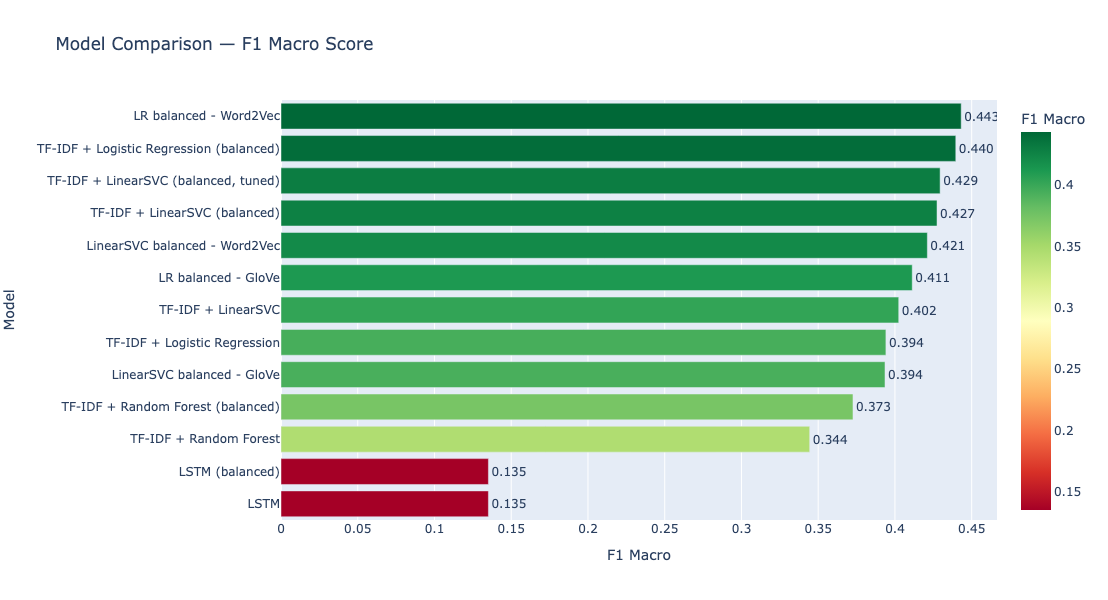

In [52]:
fig = px.bar(
    results_df[results_df['F1 Macro'].notna()].sort_values('F1 Macro', ascending=True),
    x='F1 Macro',
    y='Model',
    orientation='h',
    title='Model Comparison — F1 Macro Score',
    color='F1 Macro',
    color_continuous_scale='RdYlGn',
    text='F1 Macro'
)
fig.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=600)
fig.show()

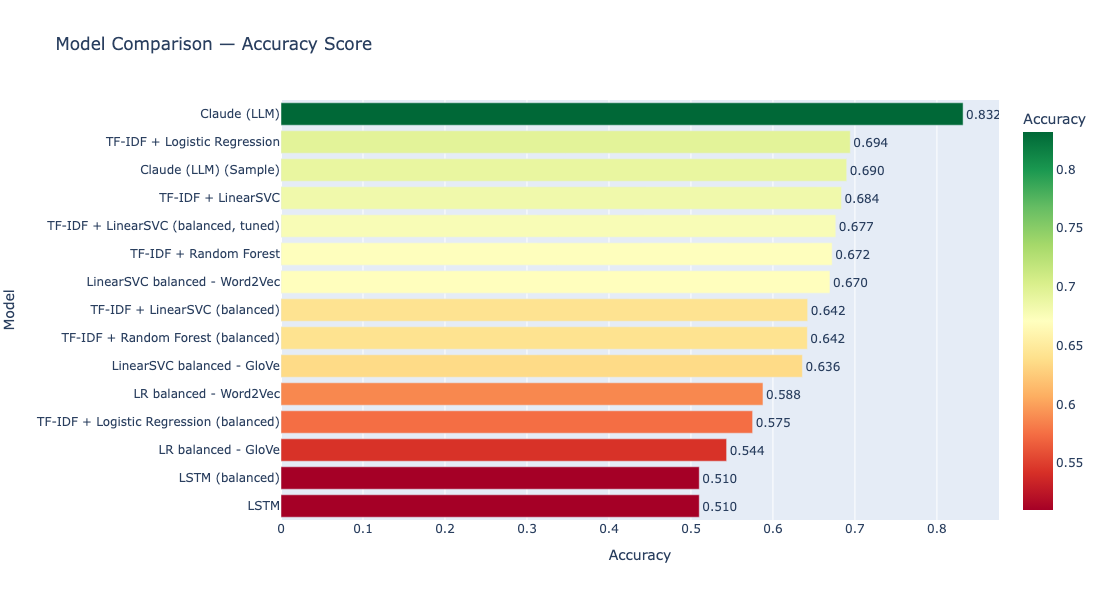

In [53]:
fig = px.bar(
    results_df[results_df['Accuracy'].notna()].sort_values('Accuracy', ascending=True),
    x='Accuracy',
    y='Model',
    orientation='h',
    title='Model Comparison — Accuracy Score',
    color='Accuracy',
    color_continuous_scale='RdYlGn',
    text='Accuracy'
)
fig.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=600)
fig.show()

## Model Comparison & Conclusions

We evaluated six approaches across three paradigms — lexicon-based, classical ML, and LLM-based — on the task of predicting sentiment from Brazilian e-commerce reviews.

**Classical ML (TF-IDF)** proved to be the strongest traditional approach, with TF-IDF + Logistic Regression achieving the highest accuracy (69.4%) among non-LLM models. However, unbalanced models are deceptive — high accuracy is driven by predicting the majority class (5-star). When evaluated on F1 macro, balanced models perform better by treating all classes equally, making them more appropriate for real-world use.

**Word embeddings** (Word2Vec, GloVe) underperformed TF-IDF on this dataset. Averaging word vectors loses word order and context, and GloVe's domain mismatch (Wikipedia vs e-commerce) actively hurt performance. Domain-trained Word2Vec outperformed pretrained GloVe — empirical evidence that pretrained embeddings don't always transfer well across domains.

**LSTM** failed entirely, defaulting to majority class prediction regardless of class weighting strategy. Short reviews (10-15 words), severe class imbalance, and linguistically indistinguishable middle classes make this dataset fundamentally unsuitable for sequential models.

**Claude (LLM)** achieves 83.2% accuracy on the full dataset — a 14 percentage point improvement over the best classical model. While this is evaluated on a simpler 3-class problem (positive/negative/neutral) making direct comparison imperfect, the crosstab results confirm Claude captures genuine sentiment signal: 94% of 1-star reviews correctly labeled negative, 93% of 5-star reviews correctly labeled positive.

The key takeaway is that LLMs don't just perform better — they understand context, negation, and nuance that word-frequency and sequential models fundamentally cannot capture on small, domain-specific, multilingual datasets.